In [1]:
import sys, os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)


# 1ère VERSION
### Ce qu'on comprend ici :
- Pourquoi la taille de position est cruciale
- Différence entre sizing binaire, fixe, et vol-targeting
- Comment la volatilité du marché doit changer notre exposition

In [2]:
# --- Imports de base ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from data.loader import download_data, compute_returns

# On charge les données AAPL (même période que les séances précédentes)
df = download_data('AAPL', '2020-01-01', '2024-01-01')
df = compute_returns(df)

print(f'Données chargées : {len(df)} jours')
print(f'Du {df.index[0].date()} au {df.index[-1].date()}')
df.tail(3)

Données chargées : 1006 jours
Du 2020-01-02 au 2023-12-29


Price,Open,High,Low,Close,Volume,returns
Date,,,,,,
2023-12-27,190.510890,191.510500,189.125276,191.164093,48087700,0.000518
2023-12-28,192.143900,192.658558,191.183873,191.589661,34049900,0.002226
2023-12-29,191.906385,192.401245,189.758698,190.550476,42672100,-0.005424


In [3]:
# --- On génère un signal simple (SMA crossover) ---
# On réutilise ce qu'on a fait en séance 4
from backtester.signals import sma_crossover

signal = sma_crossover(df['Close'], fast=20, slow=50)

print('Signal (5 premières valeurs non-NaN) :')
print(signal.dropna().head())
print(f'\nValeurs uniques du signal : {signal.dropna().unique()}')
# → sma_crossover retourne exactement +1 ou -1

Signal (5 premières valeurs non-NaN) :
Date
2020-03-16   -1.0
2020-03-17   -1.0
2020-03-18   -1.0
2020-03-19   -1.0
2020-03-20   -1.0
dtype: float64

Valeurs uniques du signal : [-1.  1.]


### Sizing Binaire 

Signal > 0 → on investit **100%** du capital  
Signal ≤ 0 → on reste en **cash (0%)**

**Problème** : quand le marché est très agité, on prend autant de risque que quand il est calme.

In [4]:
# Sizing binaire : c'est exactement ce que compute_positions() faisait en séance 2
# signal > 0 → 1, signal ≤ 0 → 0
# shift(1) → on exécute demain (pas de look-ahead bias)

position_binary = (signal > 0).astype(int).shift(1).fillna(0)

print('Position binaire — valeurs possibles :', position_binary.unique())
print(f'Jours en position : {(position_binary > 0).sum()}')
print(f'Jours en cash     : {(position_binary == 0).sum()}')

Position binaire — valeurs possibles : [0. 1.]
Jours en position : 579
Jours en cash     : 427


### Sizing Fixe

On investit toujours la même fraction du capital : 50%.

Avantage : on ne perd jamais plus de 50% d'une journée terrible.  
Inconvénient : on ignore si le marché est calme ou agité.

In [5]:
FRACTION = 0.5   # On met toujours 50% du capital

# Si signal positif → direction = 1.0, sinon → 0.0
direction = (signal > 0).astype(float)

# Taille fixe : fraction × direction
position_fixed = (direction * FRACTION).shift(1).fillna(0)

print(f'Position fixe — valeurs possibles : {position_fixed.unique()}')
print(f'Max exposure : {position_fixed.max():.0%} du capital')
print(f'(vs 100% en mode binaire)')

Position fixe — valeurs possibles : [0.  0.5]
Max exposure : 50% du capital
(vs 100% en mode binaire)


### Vol-Targeting : la logique du risque adaptatif

**Idée centrale** : on veut *toujours* prendre le même niveau de risque.

Si la volatilité du marché double → on coupe l'exposition de moitié.  
Si la volatilité baisse → on peut investir plus.

**Formule :**
```
taille = vol_cible / vol_réalisée
       = 10% / 20% = 0.50  → on met 50%
       = 10% / 5%  = 2.0   → clippé à 1.0
```

In [6]:
VOL_TARGET = 0.10   # On veut 10% de vol annuelle
WINDOW     = 20     # On mesure la vol sur 20 jours

# Étape 1 : vol réalisée (journalière → annualisée par ×√252)
vol_realized = df['returns'].rolling(WINDOW).std() * np.sqrt(252)

# Étape 2 : taille brute
raw_size = VOL_TARGET / vol_realized

# Étape 3 : on force entre 0 et 1 (pas de levier)
size = raw_size.clip(0, 1)

# Étape 4 : on applique la direction du signal
direction = (signal > 0).astype(float)
position_vol = (size * direction).shift(1).fillna(0)

# Voyons comment la taille varie avec la volatilité
comparison = pd.DataFrame({
    'vol_réalisée_%': (vol_realized * 100).round(1),
    'taille_%': (position_vol * 100).round(1)
}).dropna()

print('Vol réalisée vs Taille de position :')
print(comparison.describe().round(1))

Vol réalisée vs Taille de position :
       vol_réalisée_%  taille_%
count           986.0     986.0
mean             30.5      25.2
std              15.0      23.8
min              12.0       0.0
25%              21.2       0.0
50%              26.8      29.2
75%              35.1      43.8
max             108.0      83.2


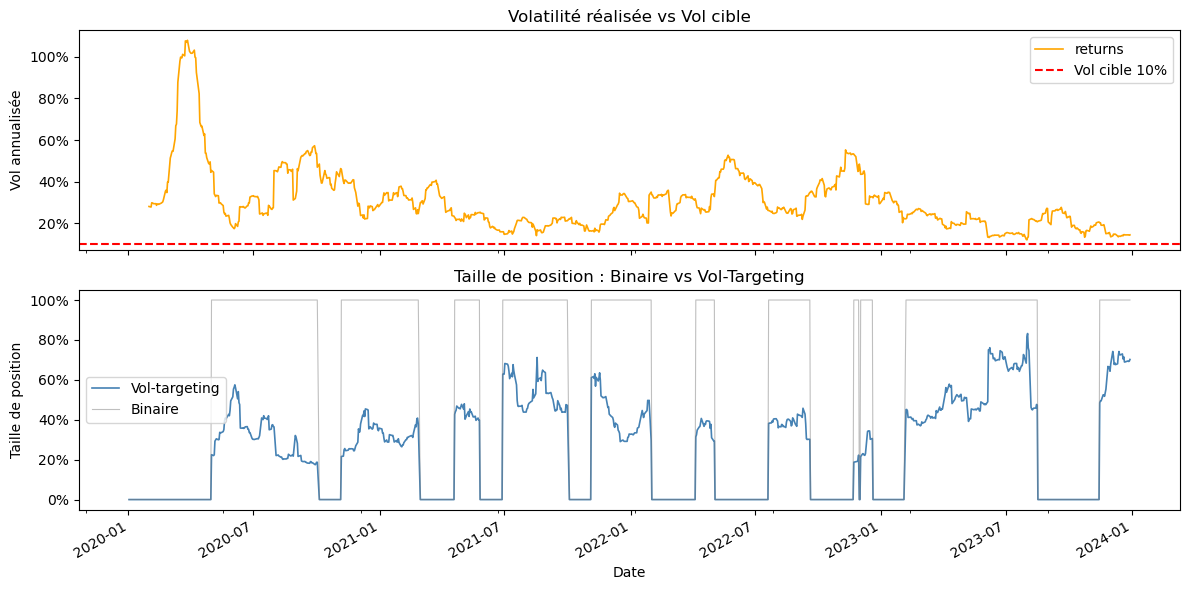


Observation : en mars 2020 (crash COVID), la vol explose → vol-targeting réduit automatiquement l'exposition.


In [7]:
# Visualisation : pourquoi vol-targeting est plus intelligent
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Graphe du haut : volatilité réalisée
vol_realized.dropna().plot(ax=ax1, color='orange', linewidth=1.2)
ax1.axhline(VOL_TARGET, color='red', linestyle='--', label=f'Vol cible {VOL_TARGET:.0%}')
ax1.set_ylabel('Vol annualisée')
ax1.set_title('Volatilité réalisée vs Vol cible')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax1.legend()

# Graphe du bas : taille de position résultante
position_vol.plot(ax=ax2, color='steelblue', linewidth=1.2, label='Vol-targeting')
position_binary.plot(ax=ax2, color='gray', alpha=0.5, linewidth=0.8, label='Binaire')
ax2.set_ylabel('Taille de position')
ax2.set_title('Taille de position : Binaire vs Vol-Targeting')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax2.legend()

plt.tight_layout()
os.makedirs(os.path.join(project_root, "reports"), exist_ok=True)
plt.savefig(os.path.join(project_root, 'reports/sizing_comparison.png'), dpi=120, bbox_inches='tight')
plt.show()
print('\nObservation : en mars 2020 (crash COVID), la vol explose → vol-targeting réduit automatiquement l\'exposition.')

=== Résultat final avec 10 000 € de départ ===
Binaire      :    16908 €
Fixe (50%)   :    13297 €
Vol-targeting:    13126 €


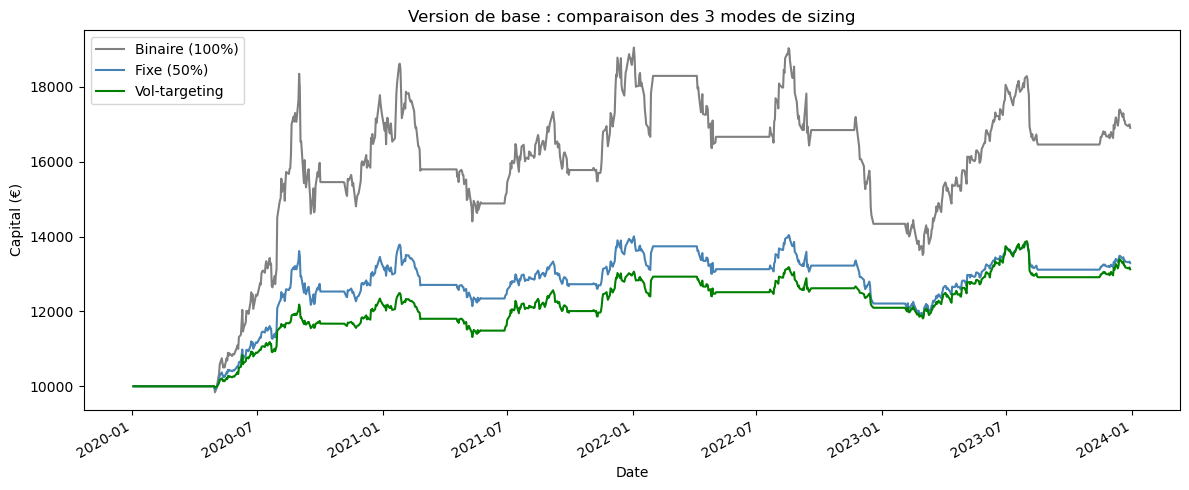

In [8]:
# Comparaison des performances — version de base
INITIAL_CAPITAL = 10_000.0

def equity_curve(position, returns, capital=INITIAL_CAPITAL):
    """Calcule la courbe de capital depuis une position."""
    strat_returns = position * returns
    cum_returns   = (1 + strat_returns).cumprod() - 1
    return capital * (1 + cum_returns)

eq_binary = equity_curve(position_binary, df['returns'])
eq_fixed  = equity_curve(position_fixed,  df['returns'])
eq_vol    = equity_curve(position_vol,    df['returns'])

# Résumé simple
print('=== Résultat final avec 10 000 € de départ ===')
print(f'Binaire      : {eq_binary.iloc[-1]:8.0f} €')
print(f'Fixe (50%)   : {eq_fixed.iloc[-1]:8.0f} €')
print(f'Vol-targeting: {eq_vol.iloc[-1]:8.0f} €')

# Graphe
fig, ax = plt.subplots(figsize=(12, 5))
eq_binary.plot(ax=ax, label='Binaire (100%)', color='gray')
eq_fixed.plot(ax=ax,  label='Fixe (50%)',     color='steelblue')
eq_vol.plot(ax=ax,    label='Vol-targeting',  color='green')
ax.set_title('Version de base : comparaison des 3 modes de sizing')
ax.set_ylabel('Capital (€)')
ax.legend()
plt.tight_layout()
plt.show()

---
#  VERSION OPTIMALE
- Kelly (critère mathématique optimal)
- Signal proportionnel (taille = force du signal)
- Stop-loss ATR (protection dynamique)
- Comparaison complète avec métriques

In [9]:
# On importe les fonctions du fichier sizing.py (version optimale)
from backtester.sizing import (
    vol_target_size,
    kelly_size,
    fixed_fraction,
    signal_proportional_size,
    atr_stop,
    compare_sizing_modes
)
from backtester.metrics import full_metrics

print('Imports OK — sizing.py chargé.')

Imports OK — sizing.py chargé.


### Kelly : le sizing mathématiquement optimal

Le critère de Kelly répond à : « Quelle fraction de mon capital mettre pour maximiser la croissance long terme ? »

**Formule :**
```
f* = (p × b - q) / b

où : p = taux de gain   (ex: 55% de jours positifs)
     q = 1 - p = taux de perte
     b = gain_moyen / perte_moyenne  (ex: 1.2)
```

En pratique on utilise le **demi-Kelly** (fraction=0.5) car :  
- Kelly plein est très agressif  
- Nos estimations de p et b sont imprécises

In [10]:
# Kelly : estimé sur une fenêtre glissante de 252 jours (1 an)
pos_kelly = kelly_size(df['returns'], signal, window=252, fraction=0.5)

print('Kelly sizing — statistiques :')
print(f'  Taille moyenne : {pos_kelly.mean():.1%}')
print(f'  Taille max     : {pos_kelly.max():.1%}')
print(f'  Taille min     : {pos_kelly.min():.1%}')
print()

# Voyons ce que Kelly calcule :
wins   = df['returns'] > 0
losses = df['returns'] <= 0

p = wins.mean()
q = 1 - p
avg_win  = df['returns'][wins].mean()
avg_loss = df['returns'][losses].abs().mean()
b = avg_win / avg_loss

kelly_full  = (p * b - q) / b
kelly_half  = kelly_full * 0.5

print(f'Stats AAPL 2020-2024 :')
print(f'  Taux de gain (p) : {p:.1%}')
print(f'  Taux de perte (q) : {q:.1%}')
print(f'  Gain moyen       : {avg_win:.3%}')
print(f'  Perte moyenne    : {avg_loss:.3%}')
print(f'  Ratio b          : {b:.2f}')
print(f'  Kelly plein (f*) : {kelly_full:.1%}')
print(f'  Demi-Kelly       : {kelly_half:.1%}')

Kelly sizing — statistiques :
  Taille moyenne : 2.3%
  Taille max     : 8.5%
  Taille min     : 0.0%

Stats AAPL 2020-2024 :
  Taux de gain (p) : 52.5%
  Taux de perte (q) : 47.5%
  Gain moyen       : 1.538%
  Perte moyenne    : 1.452%
  Ratio b          : 1.06
  Kelly plein (f*) : 7.6%
  Demi-Kelly       : 3.8%


### Signal Proportionnel : la taille suit la conviction

Quand on combine des signaux (séance 4), on obtient des valeurs entre -1 et +1.

Un signal de 0.9 = très forte conviction → on investit davantage  
Un signal de 0.1 = hésitation → on investit peu

In [11]:
# Pour montrer le signal proportionnel, on utilise un signal combiné
# (le sma_crossover ne retourne que +1/-1, on va utiliser Bollinger)
from backtester.signals import bollinger_zscore, combine_signals

sig_boll = bollinger_zscore(df['Close'])  # signal entre -1 et +1
sig_comb = combine_signals({'sma': signal, 'boll': sig_boll})

# Signal proportionnel standard
pos_prop = signal_proportional_size(sig_comb, df['returns'])

# Signal proportionnel convexe (power=2 : favorise les forts signaux)
pos_prop_conv = signal_proportional_size(sig_comb, df['returns'], power=2.0)

print('Signal proportionnel — comparaison :')
print(f'  Linéaire (power=1) — taille moyenne : {pos_prop.mean():.1%}')
print(f'  Convexe  (power=2) — taille moyenne : {pos_prop_conv.mean():.1%}')
print()
print('Avec power=2, on pénalise les signaux tièdes.')

Signal proportionnel — comparaison :
  Linéaire (power=1) — taille moyenne : 8.2%
  Convexe  (power=2) — taille moyenne : 4.8%

Avec power=2, on pénalise les signaux tièdes.


### Stop-Loss ATR : protéger le capital

**ATR = Average True Range** = mesure de la volatilité intraday.

Un stop-loss ATR s'adapte au marché :
- Marché calme (ATR faible) → stop serré
- Marché agité (ATR élevé) → stop plus large (pour ne pas se faire sortir par le bruit)

```
Stop = Close_entrée - ATR × multiplier
     = 150 € - 3 € × 2 = 144 €
```

Si le prix descend sous 144 € → on sort (position = 0).

Colonnes retournées : ['atr', 'stop_level', 'position_atr']



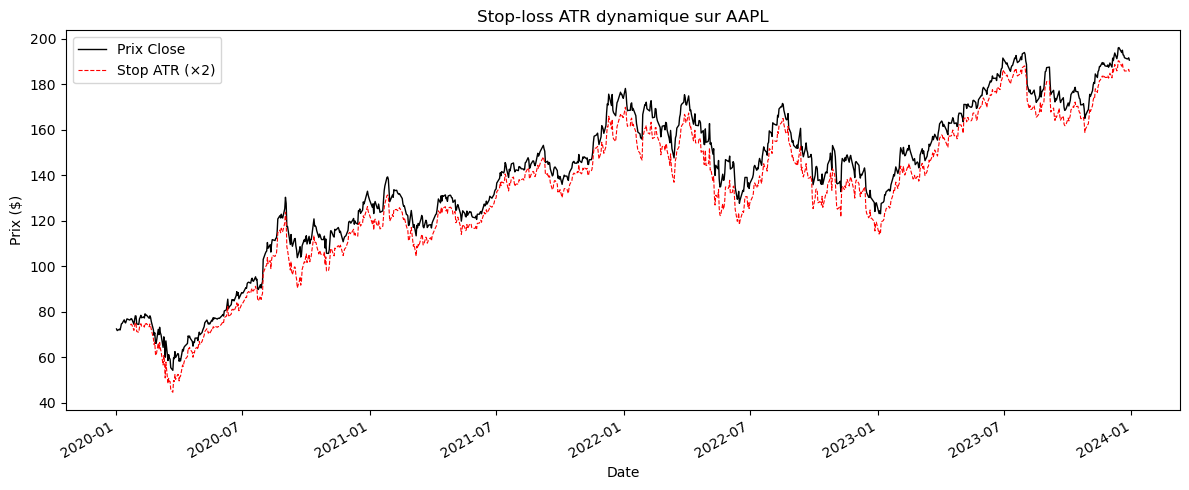

Stop déclenché : 0 fois sur 1006 jours
Soit 0.0% du temps


In [12]:
# Calcul du stop-loss ATR
atr_result = atr_stop(df, signal, atr_window=14, atr_multiplier=2.0)
print('Colonnes retournées :', atr_result.columns.tolist())
print()

# Visualiser le stop sur le prix
fig, ax = plt.subplots(figsize=(12, 5))

df['Close'].plot(ax=ax, label='Prix Close', color='black', linewidth=1)
atr_result['stop_level'].plot(ax=ax, label='Stop ATR (×2)', color='red',
                               linewidth=0.8, linestyle='--')

ax.set_title('Stop-loss ATR dynamique sur AAPL')
ax.set_ylabel('Prix ($)')
ax.legend()
plt.tight_layout()
plt.show()

# Combien de fois le stop est-il déclenché ?
stop_triggered = df['Close'] < atr_result['stop_level']
print(f'Stop déclenché : {stop_triggered.sum()} fois sur {len(df)} jours')
print(f'Soit {stop_triggered.mean():.1%} du temps')

### Comparaison Complète des 5 modes

In [13]:
# On calcule toutes les equity curves d'un coup
all_equity = compare_sizing_modes(df, signal, initial_capital=10_000.0)
print('Equity curves calculées :')
print(all_equity.columns.tolist())

Equity curves calculées :
['equity_binary', 'equity_vol', 'equity_kelly', 'equity_proportional', 'equity_atr']


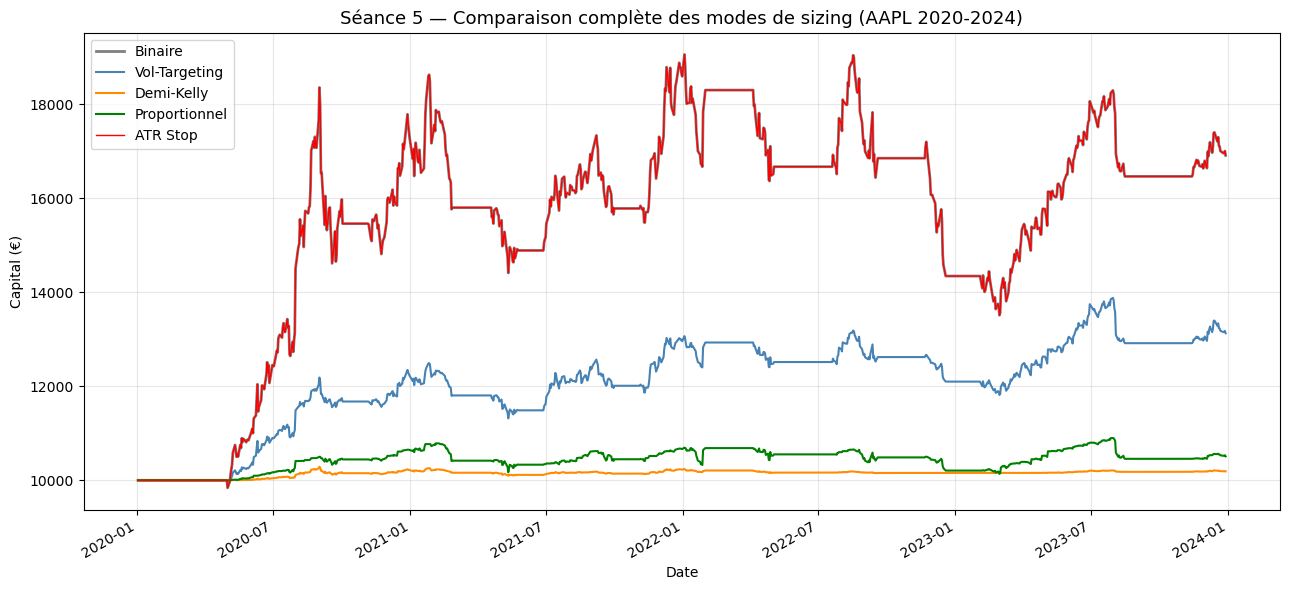

Binaire         :    16908 €  (NaN: 0)
Vol-Targeting   :    13126 €  (NaN: 0)
Demi-Kelly      :    10189 €  (NaN: 0)
Proportionnel   :    10510 €  (NaN: 0)
ATR Stop        :    16908 €  (NaN: 0)


In [16]:

# --- Calcul direct des positions (plus robuste que compare_sizing_modes) ---
def make_equity(pos, returns, capital=10_000.0):
    r = (pos * returns).fillna(0)
    return capital * (1 + r).cumprod()

pos_bin   = (signal > 0).astype(int).shift(1).fillna(0)
pos_vol2  = vol_target_size(df['returns'], signal)
pos_kel2  = kelly_size(df['returns'], signal)
pos_pro2  = signal_proportional_size(sig_comb, df['returns'])
pos_atr2  = atr_stop(df, signal)['position_atr']

curves = {
    'Binaire':       (make_equity(pos_bin,  df['returns']), 'gray',       2.0),
    'Vol-Targeting': (make_equity(pos_vol2, df['returns']), 'steelblue',  1.5),
    'Demi-Kelly':    (make_equity(pos_kel2, df['returns']), 'darkorange', 1.5),
    'Proportionnel': (make_equity(pos_pro2, df['returns']), 'green',      1.5),
    'ATR Stop':      (make_equity(pos_atr2, df['returns']), 'red',        1.0),
}

fig, ax = plt.subplots(figsize=(13, 6))
for label, (eq, color, lw) in curves.items():
    eq.plot(ax=ax, label=label, color=color, linewidth=lw)

ax.set_title('Séance 5 — Comparaison complète des modes de sizing (AAPL 2020-2024)', fontsize=13)
ax.set_ylabel('Capital (€)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
os.makedirs(os.path.join(project_root, "reports"), exist_ok=True)
plt.savefig(os.path.join(project_root, 'reports/sizing_comparison.png'), dpi=120, bbox_inches='tight')
plt.show()

# Vérification rapide
for label, (eq, _, _) in curves.items():
    print(f'{label:15s} : {eq.iloc[-1]:8.0f} €  (NaN: {eq.isna().sum()})')

In [17]:
# --- Tableau de métriques complet ---
from backtester.metrics import full_metrics

modes = {
    'Binaire':        (signal > 0).astype(int).shift(1).fillna(0),
    'Vol-Targeting':  vol_target_size(df['returns'], signal),
    'Demi-Kelly':     kelly_size(df['returns'], signal),
    'Proportionnel':  signal_proportional_size(sig_comb, df['returns']),
    'ATR Stop':       atr_stop(df, signal)['position_atr'],
}

metrics_rows = []
for name, position in modes.items():
    strat_returns = position * df['returns']
    equity        = 10_000 * (1 + strat_returns).cumprod()
    m = full_metrics(strat_returns, equity)
    m['Mode'] = name
    metrics_rows.append(m)

metrics_df = pd.DataFrame(metrics_rows).set_index('Mode')

# Afficher proprement
print('\n=== Tableau de métriques — Séance 5 ===')
print(metrics_df.to_string())


=== Tableau de métriques — Séance 5 ===
               CAGR (%)  Sharpe  Calmar  Max Drawdown (%)  Win Rate (%)  Profit Factor  VaR 95% (%)  Capital final (€)  Nb jours tradés
Mode                                                                                                                                   
Binaire           14.07    0.73    0.48            -29.09         51.47           1.18        -1.95           16907.50              578
Vol-Targeting      7.06    0.84    0.68            -10.39         51.47           1.21        -0.72           13126.40              578
Demi-Kelly         0.47    0.45    0.25             -1.88         51.79           1.13        -0.10           10189.29              532
Proportionnel      1.25    0.33    0.21             -6.03         52.07           1.10        -0.34           10509.90              533
ATR Stop          14.07    0.73    0.48            -29.09         51.47           1.18        -1.95           16907.50              578
